# **Tratamento de Dados e Pré-processamento**

Para este problema de classificação, o objetivo é prever o resultado da partida: Vitória do Mandante, Empate ou Vitória do Visitante.
A variável alvo (resultado) foi derivada comparando a coluna vencedor com a coluna mandante.
Como os algoritmos de aprendizado de máquina operam com cálculos matemáticos, eles não conseguem interpretar texto diretamente (como "Flamengo" ou "Maracanã"). Portanto, aplicou-se o método One-Hot Encoding nas variáveis categóricas independentes (mandante, visitante, estado). Essa técnica cria colunas binárias (0 ou 1) para cada categoria, eliminando qualquer viés de ordem ou hierarquia que algoritmos baseados em distância (como KNN) poderiam inferir erroneamente.
Todo esse processo foi encapsulado em um Pipeline junto com um ColumnTransformer para evitar vazamento de dados (data leakage) durante a validação cruzada.

In [1]:
import pandas as pd
import numpy as np


In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
import kagglehub
import os


path = kagglehub.dataset_download("adaoduque/campeonato-brasileiro-de-futebol")
print("Pasta base do Kaggle:", path)
caminho_csv = os.path.join(path, "campeonato-brasileiro-full.csv")
dados = pd.read_csv(caminho_csv)


c:\Gabriel\IAC\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Pasta base do Kaggle: C:\Users\rauli\.cache\kagglehub\datasets\adaoduque\campeonato-brasileiro-de-futebol\versions\18


In [4]:
dados.head(3)

,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao
0,1,1,29/03/2003,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,Guarani,Brinco de Ouro,4,2,SP,RJ,NaN
1,2,1,29/03/2003,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,Athletico-PR,Arena da Baixada,2,0,PR,RS,NaN
2,3,1,30/03/2003,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,-,Maracanã,1,1,RJ,PR,NaN


In [5]:
print(f"Quantidade de partidas registradas no dataset: {len(dados)}")

Quantidade de partidas registradas no dataset: 9165


# **Tratamento de Dados e Valores Ausentes (Missing Values)**
Durante a análise exploratória, identificou-se uma alta incidência de valores ausentes em colunas como tecnico_mandante, tecnico_visitante e formações táticas, devido à falta de registros históricos nas primeiras décadas do campeonato (a partir de 2003).

A estratégia de tratamento adotada foi:

As colunas com mais de 50% de dados faltantes (técnicos, formações e arrecadação) foram removidas do modelo, pois sua imputação causaria forte viés e sua ausência prejudicaria o aprendizado.

Para as variáveis essenciais (mandante, visitante, vencedor e Estado), caso houvesse apenas alguns valores nulos, aplicaria-se a exclusão das linhas (dropna()), garantindo que o algoritmo (Regressão Logística/KNN/SVM) recebesse uma matriz densa e consistente para o treinamento.

In [6]:
print("Valores nulos antes do tratamento:")
print(dados.isnull().sum())

Valores nulos antes do tratamento:
ID                       0
rodata                   0
data                     0
hora                     0
mandante                 0
visitante                0
formacao_mandante     4975
formacao_visitante    4975
tecnico_mandante      4610
tecnico_visitante     4610
vencedor                 0
arena                    0
mandante_Placar          0
visitante_Placar         0
mandante_Estado          0
visitante_Estado         0
arrecadacao           8785
dtype: int64


In [7]:
colunas_para_remover = ['formacao_mandante', 'formacao_visitante', 'tecnico_mandante', 'tecnico_visitante', 'arrecadacao']

In [8]:
dados = dados.drop(columns=colunas_para_remover)

In [9]:
print("Valores nulos após o tratamento:")
print(dados.isnull().sum())

Valores nulos após o tratamento:
ID                  0
rodata              0
data                0
hora                0
mandante            0
visitante           0
vencedor            0
arena               0
mandante_Placar     0
visitante_Placar    0
mandante_Estado     0
visitante_Estado    0
dtype: int64


# **Modelo 1: Regressão Logística**

In [10]:
dados['resultado'] = np.where(dados['vencedor'] == dados['mandante'], 'Mandante',
                    np.where(dados['vencedor'] == '-', 'Empate', 'Visitante'))

In [11]:
features_categoricas = ['mandante', 'visitante', 'mandante_Estado', 'visitante_Estado']

In [12]:
X = dados[features_categoricas]
y = dados['resultado']

In [13]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [14]:
pre_processador = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_categoricas)
    ])

In [15]:
pipeline = Pipeline([
    ('pre_processamento', pre_processador),
    ('classificador', LogisticRegression(max_iter=1000))
])

In [16]:
parametros = {
    'classificador__C': [0.1, 1.0, 10.0],
    'classificador__solver': ['lbfgs', 'liblinear']
}

In [17]:

grid_search = GridSearchCV(pipeline, param_grid=parametros, cv=5, scoring='accuracy', n_jobs=-1)

In [18]:
#Treinamento da Regressão Logística
grid_search.fit(X_treino, y_treino)

c:\Gabriel\IAC\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
15 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Gabriel\IAC\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Gabriel\IAC\.venv\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Gabriel\IAC\.venv\Lib\site-packages\sklearn\pipeline.py", line 649, in fit
    self._final_estimator.fit(Xt, y, **last_s

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classificador__C': [0.1, 1.0, ...], 'classificador__solver': ['lbfgs', 'liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Contro

In [19]:
print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Melhor acurácia na validação cruzada: {grid_search.best_score_:.4f}")

Melhores parâmetros encontrados: {'classificador__C': 0.1, 'classificador__solver': 'lbfgs'}
Melhor acurácia na validação cruzada: 0.4968


In [20]:
previsoes = grid_search.predict(X_teste)
print("\nRelatório de Classificação Final:")
print(classification_report(y_teste, previsoes))


Relatório de Classificação Final:
              precision    recall  f1-score   support

      Empate       0.32      0.03      0.05       727
    Mandante       0.51      0.94      0.66      1365
   Visitante       0.42      0.12      0.19       658

    accuracy                           0.50      2750
   macro avg       0.42      0.36      0.30      2750
weighted avg       0.44      0.50      0.39      2750



In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

# **Modelo 2: K-Nearest Neighbors (KNN)**

In [22]:
pipeline_knn = Pipeline([
    ('pre_processamento', pre_processador),
    ('classificador', KNeighborsClassifier())
])

In [23]:
parametros_knn = {
    'classificador__n_neighbors': [3, 5, 7],
    'classificador__weights': ['uniform', 'distance']
}

In [24]:
#Treinamento do KNN
grid_knn = GridSearchCV(pipeline_knn, param_grid=parametros_knn, cv=5, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_treino, y_treino)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classificador__n_neighbors': [3, 5, ...], 'classificador__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default

In [25]:
print(f"Melhores parâmetros KNN: {grid_knn.best_params_}")
print(f"Melhor acurácia (Validação Cruzada): {grid_knn.best_score_:.4f}")

Melhores parâmetros KNN: {'classificador__n_neighbors': 7, 'classificador__weights': 'uniform'}
Melhor acurácia (Validação Cruzada): 0.4388


In [26]:
previsoes_knn = grid_knn.predict(X_teste)

In [27]:
#Relatório de Classificação (KNN):
print(classification_report(y_teste, previsoes_knn))

              precision    recall  f1-score   support

      Empate       0.29      0.26      0.27       727
    Mandante       0.51      0.65      0.58      1365
   Visitante       0.27      0.15      0.19       658

    accuracy                           0.43      2750
   macro avg       0.36      0.35      0.35      2750
weighted avg       0.40      0.43      0.40      2750



# **Modelo 3: Árvore de Decisão**

In [28]:
pipeline_tree = Pipeline([
    ('pre_processamento', pre_processador),
    ('classificador', DecisionTreeClassifier(random_state=42))
])

In [29]:
parametros_tree = {
    'classificador__max_depth': [None, 10, 20],
    'classificador__min_samples_split': [2, 5, 10]
}

In [30]:
#Treinamento da Árvore de Decisão
grid_tree = GridSearchCV(pipeline_tree, param_grid=parametros_tree, cv=5, scoring='accuracy', n_jobs=-1)
grid_tree.fit(X_treino, y_treino)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classificador__max_depth': [None, 10, ...], 'classificador__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default

In [31]:
print(f"Melhores parâmetros Árvore: {grid_tree.best_params_}")
print(f"Melhor acurácia (Validação Cruzada): {grid_tree.best_score_:.4f}")

Melhores parâmetros Árvore: {'classificador__max_depth': 10, 'classificador__min_samples_split': 2}
Melhor acurácia (Validação Cruzada): 0.4779


In [32]:
previsoes_tree = grid_tree.predict(X_teste)
print("\nRelatório de Classificação (Árvore de Decisão):")
print(classification_report(y_teste, previsoes_tree))


Relatório de Classificação (Árvore de Decisão):
              precision    recall  f1-score   support

      Empate       0.29      0.06      0.09       727
    Mandante       0.51      0.94      0.66      1365
   Visitante       0.35      0.04      0.08       658

    accuracy                           0.49      2750
   macro avg       0.38      0.35      0.28      2750
weighted avg       0.41      0.49      0.37      2750



# **Modelo 4: Multilayer Perceptron (MLP)**

In [33]:
pipeline_mlp = Pipeline([
    ('pre_processamento', pre_processador),
    ('classificador', MLPClassifier(max_iter=500, random_state=42))
])

In [34]:
parametros_mlp = {
    'classificador__hidden_layer_sizes': [(50,), (100,)],
    'classificador__activation': ['relu', 'tanh']
}

In [35]:
#Treinamento do MLP
grid_mlp = GridSearchCV(pipeline_mlp, param_grid=parametros_mlp, cv=5, scoring='accuracy', n_jobs=-1)
grid_mlp.fit(X_treino, y_treino)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classificador__activation': ['relu', 'tanh'], 'classificador__hidden_layer_sizes': [(50,), (100,)]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, 

In [36]:
print(f"Melhores parâmetros MLP: {grid_mlp.best_params_}")
print(f"Melhor acurácia (Validação Cruzada): {grid_mlp.best_score_:.4f}")

Melhores parâmetros MLP: {'classificador__activation': 'tanh', 'classificador__hidden_layer_sizes': (100,)}
Melhor acurácia (Validação Cruzada): 0.4592


In [37]:
previsoes_mlp = grid_mlp.predict(X_teste)
print("\nRelatório de Classificação (MLP):")
print(classification_report(y_teste, previsoes_mlp))


Relatório de Classificação (MLP):
              precision    recall  f1-score   support

      Empate       0.29      0.04      0.07       727
    Mandante       0.52      0.91      0.66      1365
   Visitante       0.40      0.15      0.21       658

    accuracy                           0.50      2750
   macro avg       0.40      0.37      0.31      2750
weighted avg       0.43      0.50      0.40      2750



# **Modelo 5: Support Vector Machine (SVM)**

In [38]:
pipeline_svm = Pipeline([
    ('pre_processamento', pre_processador),
    ('classificador', SVC(random_state=42))
])

In [39]:
parametros_svm = {
    'classificador__kernel': ['linear', 'rbf'],
    'classificador__C': [0.1, 1.0]
}

In [40]:
#Treinamento do SVM
grid_svm = GridSearchCV(pipeline_svm, param_grid=parametros_svm, cv=5, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_treino, y_treino)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classificador__C': [0.1, 1.0], 'classificador__kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the ver

In [41]:
print(f"Melhores parâmetros SVM: {grid_svm.best_params_}")
print(f"Melhor acurácia (Validação Cruzada): {grid_svm.best_score_:.4f}")

Melhores parâmetros SVM: {'classificador__C': 0.1, 'classificador__kernel': 'rbf'}
Melhor acurácia (Validação Cruzada): 0.4965


In [42]:
previsoes_svm = grid_svm.predict(X_teste)
print("\nRelatório de Classificação (SVM):")
print(classification_report(y_teste, previsoes_svm))


Relatório de Classificação (SVM):
              precision    recall  f1-score   support

      Empate       0.00      0.00      0.00       727
    Mandante       0.50      1.00      0.66      1365
   Visitante       0.00      0.00      0.00       658

    accuracy                           0.50      2750
   macro avg       0.17      0.33      0.22      2750
weighted avg       0.25      0.50      0.33      2750



c:\Gabriel\IAC\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Gabriel\IAC\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Gabriel\IAC\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# **Comparação Entre os Modelos Treinados**

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
acuracias = {
    'Regressão Logística': grid_search.score(X_teste, y_teste),
    'KNN': grid_knn.score(X_teste, y_teste),
    'Árvore de Decisão': grid_tree.score(X_teste, y_teste),
    'MLP (Redes Neurais)': grid_mlp.score(X_teste, y_teste),
    'SVM': grid_svm.score(X_teste, y_teste)
}

C:\Users\rauli\AppData\Local\Temp\ipykernel_15944\1370841802.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(x=list(acuracias.keys()), y=list(acuracias.values()), palette='viridis')


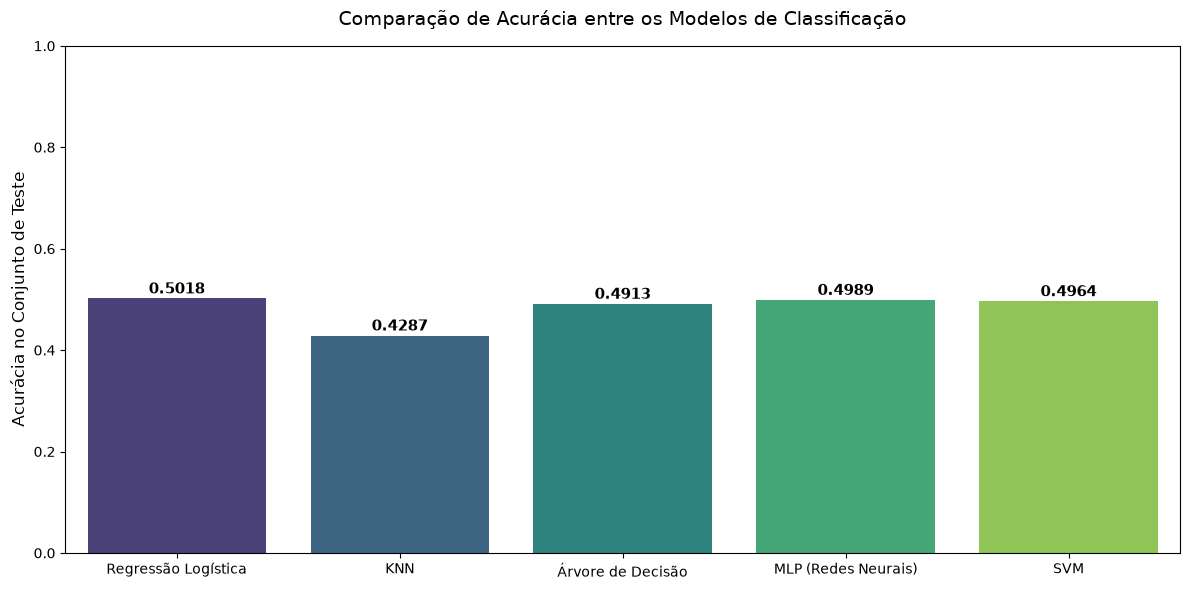

In [45]:
plt.figure(figsize=(12, 6))
grafico = sns.barplot(x=list(acuracias.keys()), y=list(acuracias.values()), palette='viridis')

plt.title('Comparação de Acurácia entre os Modelos de Classificação', fontsize=14, pad=15)
plt.ylabel('Acurácia no Conjunto de Teste', fontsize=12)
plt.ylim(0, 1)

for i, v in enumerate(acuracias.values()):
    grafico.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

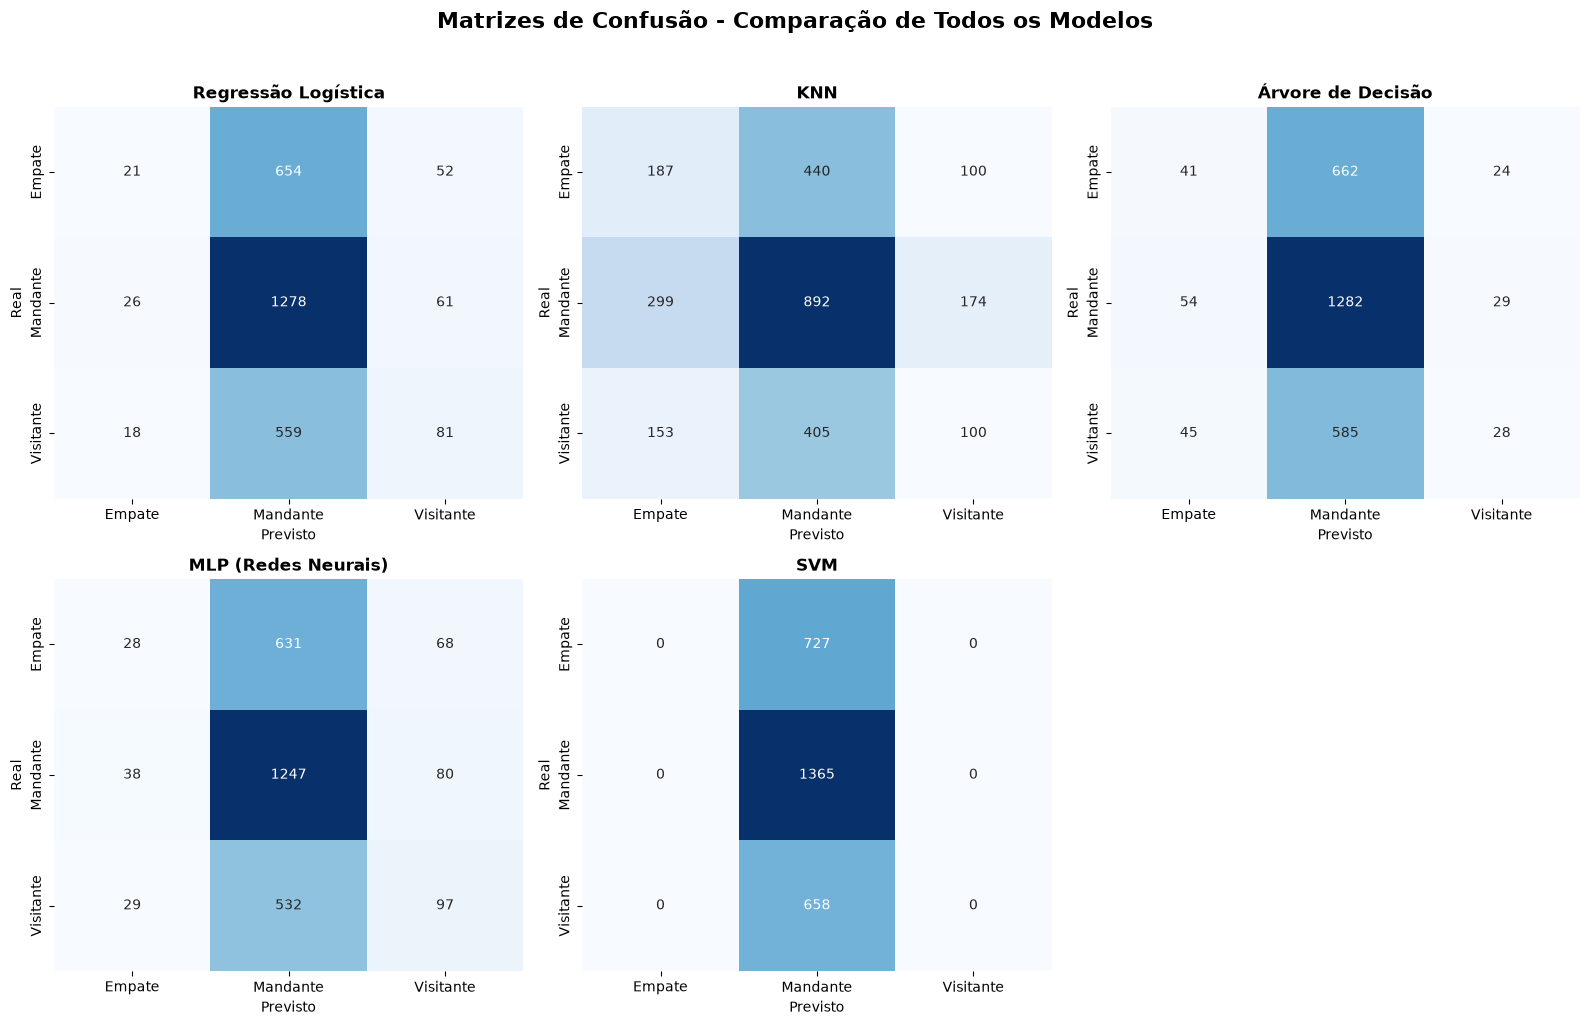

In [46]:
modelos_treinados = {
    'Regressão Logística': grid_search,
    'KNN': grid_knn,
    'Árvore de Decisão': grid_tree,
    'MLP (Redes Neurais)': grid_mlp,
    'SVM': grid_svm
}

# Cria uma figura grande com uma grade de 2 linhas e 3 colunas
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
fig.suptitle('Matrizes de Confusão - Comparação de Todos os Modelos', fontsize=16, fontweight='bold', y=1.02)

# Achata a matriz de eixos para facilitar o loop
axes = axes.flatten()

# Classes no formato correto
classes_nomes = grid_search.classes_

# Loop para plotar cada matriz em um "quadradinho" da grade
for ax, (nome, modelo) in zip(axes, modelos_treinados.items()):
    # Faz a previsão com o modelo atual
    previsoes_atuais = modelo.predict(X_teste)

    # Calcula a matriz
    cm = confusion_matrix(y_teste, previsoes_atuais, labels=classes_nomes)

    # Plota o mapa de calor
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=classes_nomes, yticklabels=classes_nomes)

    ax.set_title(nome, fontsize=12, fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Previsto')

axes[5].axis('off')

plt.tight_layout()
plt.show()